# Entity / lexicon counts on `df_combined`

Loads [`df_combined.csv`](../00_Initial%20EDA/df_combined.csv) and analyses **mainstream-media-related** German terms in the **`Text`** column (case-insensitive substring counts).

In [10]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

_cwd = Path.cwd().resolve()
if (_cwd / "01_EDAperOutlet" / "outputs" / "df_combined.csv").is_file():
    THESIS_ROOT = _cwd
elif (_cwd.parent / "01_EDAperOutlet" / "outputs" / "df_combined.csv").is_file():
    THESIS_ROOT = _cwd.parent
else:
    THESIS_ROOT = Path("/Users/gretawette/Documents/Thesis")

DATA_PATH = THESIS_ROOT / "01_EDAperOutlet" / "outputs" / "df_combined.csv"
print("DATA_PATH:", DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

TEXT_COL = "Text"
OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column; columns: {list(df.columns)}")
if TEXT_COL not in df.columns:
    raise KeyError(f"Expected column {TEXT_COL!r}; columns: {list(df.columns)}")

print(f"Rows: {len(df):,} | Outlets: {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL, TEXT_COL]].head(2)

DATA_PATH: /Users/gretawette/Documents/Thesis/00_Initial EDA/df_combined.csv
Rows: 20,440 | Outlets: 7


,source,Text
0,Antispiegel,Der Streit um das Nationale Anti-Korruptionsbü...
1,Antispiegel,Die New York Times versucht seit langem vor Ge...


## Mainstream media lexicon (substring counts)

Each term is counted with `str.count` on the lowercased article text (non-overlapping matches per term). Row total = **sum over terms** (one article can contribute multiple hits across different terms).

In [22]:
MAINSTREAM_MEDIA_LEXICON = [
    # Specific outlets
    # "tagesschau",
    # "tagesthemen",
    # "ard",
    # "zdf",
    # "spiegel",
    # "süddeutsche",
    # "sueddeutsche",
    # "faz",
    # "frankfurter allgemeine",
    # "welt",
    # "focus",
    # "stern",
    # "bild",
    # "handelsblatt",
    # "ntv",
    # "n-tv",
    # "phoenix",
    # "3sat",
    # "arte",
    # "deutschlandfunk",
    # "dlf",
    # "dpa",
    # "reuters",
    # "ap ",
    # "afp",
    # "spiegel online",
    # "tagesschau online",
    # "tagesschau.de",
    # "tagesschau.de/video",
    # "tagesschau.de/video/",
    # "tagesschau.de/video/",
    
    # Generic terms for mainstream / establishment media
    "mainstream",
    "systempresse",
    "staatsmedien",
    "staatsfunk",
    "öffentlich-rechtlich",
    "oeffentlich-rechtlich",
    "qualitätspresse",
    "qualitaetspresse",
    "leitmedien",
    "einheitsmedien",
    "gleichschaltung",
    "propagandamedien",
    "propagandasender",
    "medienkonzern",
    "pressefreiheit",
    "zensur",
    "meinungsmache",
    # Journalists / editors as a class
    "redaktion",
    "chefredakteur",
    "journalist",
    "korrespondent",
    "moderator",
    "nachrichtensprecher",
    "kommentator",

    "mainstreammedien",
    "mainstream medien", 
    "lügenpresse",
    "systemmedien",
    "systempresse",
    "staatsmedien",
    "staatsfunk",
    "öffentlich-rechtlich",
    "oeffentlich-rechtlich",
    "qualitätspresse",
    "qualitaetspresse",
    "massenmedien"
]

_LEX_LOWER = [t.lower() for t in MAINSTREAM_MEDIA_LEXICON]


def count_mainstream_lexicon_hits(text: object) -> int:
    if not isinstance(text, str) or not text.strip():
        return 0
    t = text.lower()
    return sum(t.count(term) for term in _LEX_LOWER)


df["mainstream_lexicon_hits"] = df[TEXT_COL].map(count_mainstream_lexicon_hits)

tagesschau_name = "Tagesschau"
df["outlet_group"] = df[OUTLET_COL].apply(
    lambda x: "Tagesschau" if x == tagesschau_name else "Alternative Medien"
)

print(
    "Total lexicon hits (all articles):",
    int(df["mainstream_lexicon_hits"].sum()),
)
print(
    "Articles with ≥1 hit:",
    int((df["mainstream_lexicon_hits"] > 0).sum()),
    f"({100 * (df['mainstream_lexicon_hits'] > 0).mean():.2f}%)",
)
df[[OUTLET_COL, "outlet_group", "mainstream_lexicon_hits"]].head(10)

Total lexicon hits (all articles): 12915
Articles with ≥1 hit: 4967 (24.30%)


,source,outlet_group,mainstream_lexicon_hits
0,Antispiegel,Alternative Medien,2
1,Antispiegel,Alternative Medien,4
2,Antispiegel,Alternative Medien,1
3,Antispiegel,Alternative Medien,4
4,Antispiegel,Alternative Medien,1
5,Antispiegel,Alternative Medien,3
6,Antispiegel,Alternative Medien,0
7,Antispiegel,Alternative Medien,1
8,Antispiegel,Alternative Medien,0
9,Antispiegel,Alternative Medien,0


### Aggregates by outlet and by `outlet_group`

In [23]:
by_outlet = (
    df.groupby(OUTLET_COL, observed=True)["mainstream_lexicon_hits"]
    .agg(total_hits="sum", articles="count", mean_hits_per_article="mean")
    .sort_values("total_hits", ascending=False)
)
by_outlet["mean_hits_per_article"] = by_outlet["mean_hits_per_article"].round(4)

by_group = (
    df.groupby("outlet_group", observed=True)["mainstream_lexicon_hits"]
    .agg(total_hits="sum", articles="count", mean_hits_per_article="mean")
    .sort_values("total_hits", ascending=False)
)
by_group["mean_hits_per_article"] = by_group["mean_hits_per_article"].round(4)

display(by_outlet)
display(by_group)

,total_hits,articles,mean_hits_per_article
source,,,
Tichys_Einblick,3046,2756,1.1052
Nius,3010,3269,0.9208
RT_de,2407,4560,0.5279
Tagesschau,2291,6320,0.3625
Compact,788,1486,0.5303
Antispiegel,785,565,1.3894
Deutschlandkurier,588,1484,0.3962


,total_hits,articles,mean_hits_per_article
outlet_group,,,
Alternative Medien,10624,14120,0.7524
Tagesschau,2291,6320,0.3625


In [24]:
# Show the top lexicon term hits per outlet (OUTLET_COL) and overall

from collections import Counter

top_n = 10  # Show top N terms per outlet and overall

# Per outlet: find top terms for each outlet
per_outlet_top_terms = {}
for outlet, subdf in df.groupby(OUTLET_COL):
    outlet_text = " ".join(subdf[TEXT_COL].fillna("").map(str)).lower()
    term_counts = Counter()
    for term in _LEX_LOWER:
        count = outlet_text.count(term)
        if count > 0:
            term_counts[term] = count
    top_terms = term_counts.most_common(top_n)
    per_outlet_top_terms[outlet] = top_terms

# Overall (all outlets combined): top terms in the full corpus
all_text = " ".join(df[TEXT_COL].fillna("").map(str)).lower()
overall_counts = Counter()
for term in _LEX_LOWER:
    count = all_text.count(term)
    if count > 0:
        overall_counts[term] = count
overall_top_terms = overall_counts.most_common(top_n)

# Display per-outlet top terms
print("Per outlet, top lexicon terms:")
for outlet, terms in per_outlet_top_terms.items():
    print(f"Top {top_n} lexicon terms for outlet '{outlet}':")
    for term, count in terms:
        print(f"  {term!r}: {count}")
    print()

# Display overall top terms
print(f"Overall (all outlets), top {top_n} lexicon terms:")
for term, count in overall_top_terms:
    print(f"  {term!r}: {count}")

# Collect all results in a single DataFrame for potential analysis/visualization
records = []
for outlet, terms in per_outlet_top_terms.items():
    for term, count in terms:
        records.append({"source": outlet, "term": term, "count": count, "level": "per_outlet"})
for term, count in overall_top_terms:
    records.append({"source": "ALL", "term": term, "count": count, "level": "overall"})

top_terms_df = pd.DataFrame(records)
display(top_terms_df)

Per outlet, top lexicon terms:
Top 10 lexicon terms for outlet 'Antispiegel':
  'journalist': 361
  'korrespondent': 150
  'redaktion': 57
  'mainstream': 53
  'zensur': 51
  'moderator': 46
  'chefredakteur': 24
  'kommentator': 20
  'pressefreiheit': 12
  'medienkonzern': 4

Top 10 lexicon terms for outlet 'Compact':
  'mainstream': 226
  'journalist': 203
  'chefredakteur': 60
  'zensur': 53
  'redaktion': 41
  'moderator': 41
  'öffentlich-rechtlich': 33
  'kommentator': 23
  'lügenpresse': 15
  'pressefreiheit': 14

Top 10 lexicon terms for outlet 'Deutschlandkurier':
  'journalist': 138
  'zensur': 73
  'chefredakteur': 73
  'mainstream': 57
  'redaktion': 43
  'öffentlich-rechtlich': 37
  'korrespondent': 33
  'pressefreiheit': 25
  'staatsfunk': 19
  'moderator': 17

Top 10 lexicon terms for outlet 'Nius':
  'journalist': 827
  'moderator': 426
  'öffentlich-rechtlich': 403
  'zensur': 227
  'redaktion': 216
  'chefredakteur': 193
  'pressefreiheit': 77
  'korrespondent': 60
  

,source,term,count,level
0,Antispiegel,journalist,361,per_outlet
1,Antispiegel,korrespondent,150,per_outlet
2,Antispiegel,redaktion,57,per_outlet
3,Antispiegel,mainstream,53,per_outlet
4,Antispiegel,zensur,51,per_outlet
...,...,...,...,...
75,ALL,korrespondent,727,overall
76,ALL,mainstream,666,overall
77,ALL,chefredakteur,601,overall
78,ALL,pressefreiheit,298,overall


In [27]:
# Show example articles and specific sentences where 'massenmedien', 'lügenpresse', or 'mainstream' are mentioned

example_terms = ["mainstream", "massenmedien", "lügenpresse"]

import re

for term in example_terms:
    print(f"\nExample articles with the term '{term}' and the specific sentence(s) mentioning it:\n")
    mask = df[TEXT_COL].str.lower().str.contains(term)
    # Show first 2 matching articles per term
    examples = df[mask].head(2)
    if not examples.empty:
        for idx, row in examples.iterrows():
            outlet = row[OUTLET_COL]
            text = str(row[TEXT_COL])
            # Split into sentences (naive split on .!?)
            sentences = re.split(r'(?<=[.!?])\s+', text)
            # Find all sentences mentioning the term (case-insensitive)
            matching_sents = [s for s in sentences if term in s.lower()]
            print(f"Outlet: {outlet}")
            print(f"Full text:")
            print(text)
            print("Sentence(s) mentioning the term:")
            if matching_sents:
                for s in matching_sents:
                    print(f"- {s}")
            else:
                print("[No sentence found containing the term -- likely edge split artifact.]")
            print()
    else:
        print(f"No articles mentioning '{term}' found.\n")


Example articles with the term 'mainstream' and the specific sentence(s) mentioning it:

Outlet: Antispiegel
Full text:
Das größte Problem der ukrainischen Streitkräfte ist der Personalmangel. Während sich in Russland jeden Monat etwa 30.000 Männer freiwillig für den Dienst im Kriegsgebiet melden, müssen die ukrainischen Streitkräfte seit Langem auf brutale Zwangsrekrutierungen zurückgreifen. Dabei werden Männer brutal auf der Straße, in öffentlichen Verkehrsmitteln, in Geschäften und so weiter eingefangen, mit Gewalt in Busse gestopft und in Kasernen gebracht. Wenn die Opfer sich wehren, werden sie zusammengeschlagen, auch Todesfälle sind dabei keine Seltenheit mehr. Aber selbst trotz dieser Maßnahmen kann die Ukraine ihre Verluste an der Front schon lange nicht mehr ausgleichen. Wer sich als Deutscher in alternativen Medien informiert, kennt die schockierenden Videos dieser Vorgänge, die empörte Ukrainer seit bestimmt einem Jahr in großer Zahl in sozialen Netzwerken posten. Da die M

### Bar chart: total lexicon hits per outlet

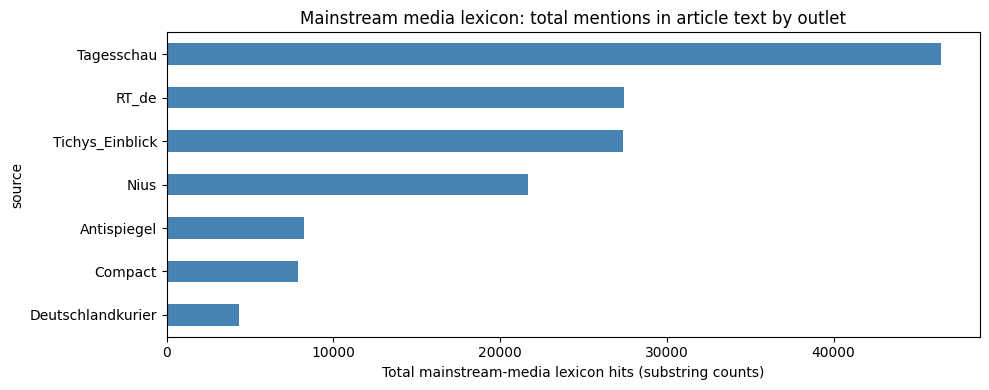

In [13]:
plot_df = (
    df.groupby(OUTLET_COL, observed=True)["mainstream_lexicon_hits"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
plot_df.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Total mainstream-media lexicon hits (substring counts)")
ax.set_ylabel(OUTLET_COL)
ax.set_title("Mainstream media lexicon: total mentions in article text by outlet")
plt.tight_layout()
plt.show()